In [1]:
import os
import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
dj.config.load("/home/sgao/source/spyglass/notebooks/dj_local_conf.json")  # load config for database connection info

import spyglass.common as sgc
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
import spyglass.lfp as sglfp
import spyglass.lfp as lfp
from spyglass.position import PositionOutput
from spyglass.lfp.v1.lfp_artifact import (
    LFPArtifactDetection,
    LFPArtifactDetectionParameters,
    LFPArtifactDetectionSelection,
)
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

# ignore datajoint+jupyter async warnings
import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-10-07 13:23:01,356][INFO]: DataJoint is configured from /home/sgao/source/spyglass/notebooks/dj_local_conf.json
[2026-10-07 13:23:01,912][INFO]: DataJoint 0.14.5 connected to sgao@lmf-db.cin.ucsf.edu:3306


In [2]:
import pynwb

nwb_file_name = "Caius20260623_.nwb"

io = pynwb.NWBHDF5IO(
    "/stelmo/nwb/raw/Caius20260623_.nwb",
    mode="r"
)

nwbf = io.read()

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-pose - cached version: 0.3.0, loaded version: 0.2.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Offline Analysis

In [3]:
nwb_file_name = "Caius20260623_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

results = []

for session in sleep_sessions:

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    results.append({
        "session": session,
        "n_ripples": len(ripple_times),
    })

ripple_counts = pd.DataFrame(results)

ripple_counts

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 2/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py

,session,n_ripples
0,01_s1,1055
1,03_s2,1323
2,05_s3,1449
3,07_s4,1722
4,09_s5,1996
5,11_s6,2029


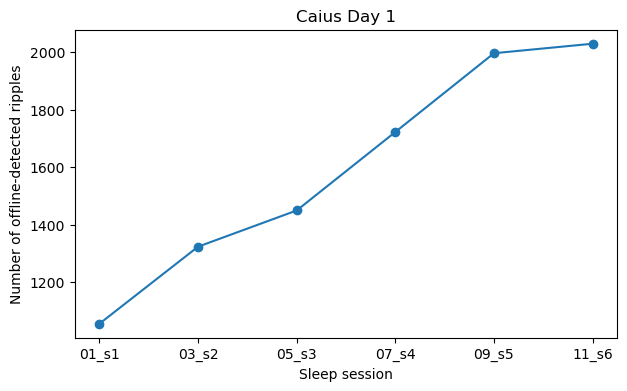

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    ripple_counts["session"],
    ripple_counts["n_ripples"],
    marker="o"
)

plt.xlabel("Sleep session")
plt.ylabel("Number of offline-detected ripples")
plt.title("Caius Day 1")

plt.show()

In [5]:
import pandas as pd

nwb_file_name = "Caius20260623_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

results = []

for session in sleep_sessions:

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe()

    n_ripples = len(ripple_times)

    first_ripple = ripple_times["start_time"].min()
    last_ripple = ripple_times["end_time"].max()

    duration_sec = last_ripple - first_ripple
    duration_min = duration_sec / 60

    ripple_rate = n_ripples / duration_min

    results.append({
        "session": session,
        "n_ripples": n_ripples,
        "duration_min": duration_min,
        "ripples_per_min": ripple_rate,
    })

ripple_summary = pd.DataFrame(results)

ripple_summary

,session,n_ripples,duration_min,ripples_per_min
0,01_s1,1055,39.957698,26.402923
1,03_s2,1323,39.967180,33.102160
2,05_s3,1449,39.956465,36.264469
3,07_s4,1722,40.977015,42.023559
4,09_s5,1996,40.054176,49.832507
5,11_s6,2029,40.972574,49.520930


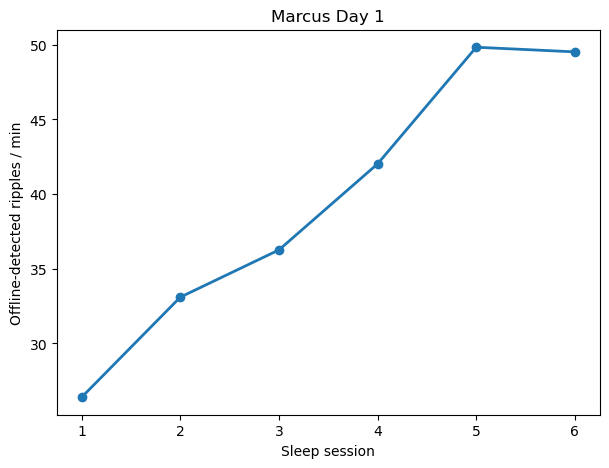

In [6]:
import matplotlib.pyplot as plt

ripple_summary["session_number"] = [1, 2, 3, 4, 5, 6]

plt.figure(figsize=(7, 5))

plt.plot(
    ripple_summary["session_number"],
    ripple_summary["ripples_per_min"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Offline-detected ripples / min")
plt.title("Marcus Day 1")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.show()
ripple_summary_day1 = ripple_summary.copy()

In [7]:
sgrip.RippleTimesV1() & {"nwb_file_name": 'Caius20260623_.nwb'}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,group_name,ripple_param_name a name for this set of parameters,pos_merge_id,analysis_file_name name of the file,ripple_times_object_id
126b0b12-17e8-0eb3-299a-f4626158aff6,Ripple 150-250 Hz,1000,Caius20260623_.nwb,09_s5,1000,Ripple Detection Channels,default_trodes,98536bb7-8722-8a71-70ce-0464aba4c7ae,Caius20260623_9WTUG0IO7S.nwb,3e73dff6-e700-4db8-a249-a6cd9c4489a5
16773d5d-e4fb-77ff-7970-58476e8fd71c,Ripple 150-250 Hz,1000,Caius20260623_.nwb,04_r2,1000,Ripple Detection Channels,default_trodes,595f4360-7eeb-794b-5004-ff086b5212bd,Caius20260623_JXDIW500O9.nwb,394cd5d4-f39c-4c29-b08f-9f50b88a92b1
2867f68a-928a-c2cf-7dc3-9ef1fb79d6fc,Ripple 150-250 Hz,1000,Caius20260623_.nwb,02_r1,1000,Ripple Detection Channels,default_trodes,511a2056-0dff-cc2a-0d97-db879dec1952,Caius20260623_3INEUIG6UX.nwb,b84fd489-be5a-4c3e-bf6a-4efc6c956eb4
89d6fd49-05e6-951e-7a1a-bc3bf07ceef5,Ripple 150-250 Hz,1000,Caius20260623_.nwb,07_s4,1000,Ripple Detection Channels,default_trodes,0bd2a477-da2d-e6f2-e1f1-e080817a3eb5,Caius20260623_7GW6XQLBEX.nwb,6e01145a-dc5d-4e5a-8372-0b43c210098d
92f85cc0-52dc-c5a4-6378-deeffff2c9cd,Ripple 150-250 Hz,1000,Caius20260623_.nwb,05_s3,1000,Ripple Detection Channels,default_trodes,5bda5b95-d1cf-6a00-ad5d-f93589e5d7a8,Caius20260623_SH4F51BBGI.nwb,185daa7b-b52e-4fe7-97e1-06f5d7dc2f36
99c1b76d-d1ca-3247-73a6-de918f57fab9,Ripple 150-250 Hz,1000,Caius20260623_.nwb,08_r4,1000,Ripple Detection Channels,default_trodes,664c41c2-1ba5-9ae1-a4ef-5e28d8b000ae,Caius20260623_0PMQ6DNI3S.nwb,800497f3-5ee6-4548-a969-e5f4f3c18c76
9dd05181-effa-bd20-c235-235ce2460123,Ripple 150-250 Hz,1000,Caius20260623_.nwb,10_r5,1000,Ripple Detection Channels,default_trodes,3a3fb618-647b-f52b-fb62-72c19cc8a473,Caius20260623_8ONLT2E6RY.nwb,4c455d03-31fa-4783-aac9-a1aafe573084
ab6ccfc9-d39f-7ee4-c20d-b7c029443ac1,Ripple 150-250 Hz,1000,Caius20260623_.nwb,11_s6,1000,Ripple Detection Channels,default_trodes,9e78f935-a9fb-7cf1-8f5a-8b04a7d217a6,Caius20260623_AI7JLZOPJG.nwb,3a618c24-73b5-4f73-ba9a-24aa7946ade3
be03eb22-d74e-5c71-2981-7b58685d6e2a,Ripple 150-250 Hz,1000,Caius20260623_.nwb,06_r3,1000,Ripple Detection Channels,default_trodes,5f1240f9-46c7-d61e-60e1-acc64e8c5e6b,Caius20260623_XMULDMHH5J.nwb,773303b1-7eea-456f-b25a-85245d8e5a3e
c985bbf5-78d5-36fc-c239-0836281967a8,Ripple 150-250 Hz,1000,Caius20260623_.nwb,01_s1,1000,Ripple Detection Channels,default_trodes,5973bd2f-c405-a142-a2ad-7ed9be79e5b7,Caius20260623_RM2L44RGHY.nwb,5d107d85-aeaf-48e6-9d97-c4d183258616


In [8]:
lfp_band_key = {'lfp_merge_id': 'c985bbf5-78d5-36fc-c239-0836281967a8',
 'filter_name': 'Ripple 150-250 Hz',
 'filter_sampling_rate': 1000,
 'nwb_file_name': 'Caius20260623_.nwb',
 'target_interval_list_name': '01_s1',
 'lfp_band_sampling_rate': 1000,
 'group_name': 'Ripple Detection Channels'}

In [9]:
rip_sel_key = (sgrip.RippleLFPSelection & lfp_band_key).fetch1("KEY")

In [10]:
interval = rip_sel_key["target_interval_list_name"]

ripple_times = (
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": 'Caius20260623_.nwb',
        "target_interval_list_name": interval,
        "ripple_param_name": "default_trodes",
    }
).fetch1_dataframe()
ripple_times

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,1.782234e+09,1.782234e+09,0.107001,6.291710,2.901181,1.858846,7.744081,0.007501,0.313284,1.537108,3.199671,1.067247,3.199671,1.067247,1.893283,1.978475
1,1.782234e+09,1.782234e+09,0.043000,3.336152,2.405518,2.395219,4.816942,0.005702,0.105812,0.371630,0.320478,0.295660,0.320478,0.295660,0.305970,0.306609
2,1.782234e+09,1.782234e+09,0.041001,2.003031,1.939481,1.687046,4.071748,0.074350,0.081373,0.215896,0.256490,0.202593,0.256490,0.202593,0.231384,0.230720
3,1.782234e+09,1.782234e+09,0.068001,5.015040,3.041650,3.034158,6.649231,0.027488,0.209846,0.937004,0.268053,0.280320,0.280320,0.266374,0.268152,0.270127
4,1.782234e+09,1.782234e+09,0.205002,3.435839,1.479516,1.188381,4.498012,0.008285,0.304756,0.671906,2.649506,1.083185,2.649506,0.958096,1.201039,1.452287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,1.782236e+09,1.782236e+09,0.101001,3.810662,2.026358,1.431048,6.001969,0.019833,0.206631,0.702752,0.277426,0.468688,0.473208,0.277426,0.440456,0.416929
1051,1.782236e+09,1.782236e+09,0.052001,4.455658,3.121137,2.652605,6.171281,0.013536,0.165367,0.699532,0.365225,0.346605,0.375149,0.346605,0.369942,0.367282
1052,1.782236e+09,1.782236e+09,0.083001,2.030985,0.960612,0.682437,3.048289,0.040911,0.080621,0.146948,1.568505,2.235135,2.235135,1.568505,1.925506,1.916891


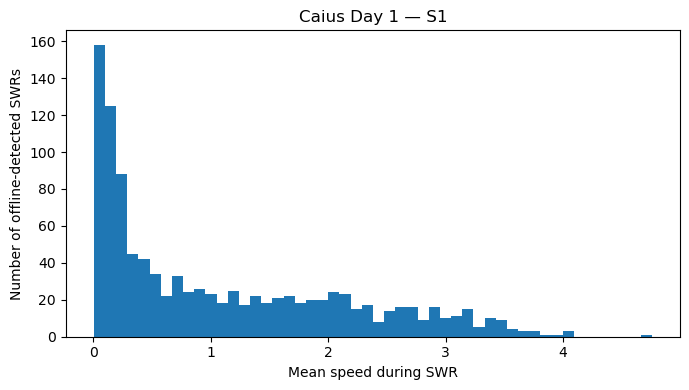

In [11]:
plt.figure(figsize=(7, 4))

plt.hist(
    ripple_times["mean_speed"],
    bins=50
)

plt.xlabel("Mean speed during SWR")
plt.ylabel("Number of offline-detected SWRs")
plt.title("Caius Day 1 — S1")

plt.tight_layout()
plt.show()

In [12]:
speed_threshold = 4  # cm/s

ripple_times["moving"] = (
    ripple_times["mean_speed"] > speed_threshold
)

In [13]:
n_total = len(ripple_times)
n_moving = ripple_times["moving"].sum()
n_not_moving = n_total - n_moving

percent_moving = (n_moving / n_total) * 100

print("Total offline SWRs:", n_total)
print("Moving SWRs:", n_moving)
print("Not moving SWRs:", n_not_moving)
print(f"Percent moving: {percent_moving:.2f}%")

Total offline SWRs: 1055
Moving SWRs: 4
Not moving SWRs: 1051
Percent moving: 0.38%


Duration

In [14]:
import pandas as pd

nwb_file_name = "Caius20260623_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

all_ripples = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    ).fetch1_dataframe().copy()

    ripple_times["session_number"] = session_number
    ripple_times["session"] = session

    all_ripples.append(ripple_times)

all_ripples = pd.concat(all_ripples, ignore_index=True)

all_ripples

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,session_number,session
0,1.782234e+09,1.782234e+09,0.107001,6.291710,2.901181,1.858846,7.744081,0.007501,0.313284,1.537108,3.199671,1.067247,3.199671,1.067247,1.893283,1.978475,1,01_s1
1,1.782234e+09,1.782234e+09,0.043000,3.336152,2.405518,2.395219,4.816942,0.005702,0.105812,0.371630,0.320478,0.295660,0.320478,0.295660,0.305970,0.306609,1,01_s1
2,1.782234e+09,1.782234e+09,0.041001,2.003031,1.939481,1.687046,4.071748,0.074350,0.081373,0.215896,0.256490,0.202593,0.256490,0.202593,0.231384,0.230720,1,01_s1
3,1.782234e+09,1.782234e+09,0.068001,5.015040,3.041650,3.034158,6.649231,0.027488,0.209846,0.937004,0.268053,0.280320,0.280320,0.266374,0.268152,0.270127,1,01_s1
4,1.782234e+09,1.782234e+09,0.205002,3.435839,1.479516,1.188381,4.498012,0.008285,0.304756,0.671906,2.649506,1.083185,2.649506,0.958096,1.201039,1.452287,1,01_s1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9569,1.782256e+09,1.782256e+09,0.113002,2.776148,1.362441,0.944868,3.771949,0.031166,0.155249,0.352761,0.070235,0.126782,0.126782,0.070235,0.082183,0.087968,6,11_s6
9570,1.782256e+09,1.782256e+09,0.051001,2.308120,1.438262,1.284131,2.852769,0.017161,0.074757,0.157722,0.072409,0.039623,0.072409,0.039623,0.055890,0.055831,6,11_s6
9571,1.782256e+09,1.782256e+09,0.061001,2.305397,1.851499,1.504865,4.307894,0.049084,0.114711,0.296883,1.321057,1.039510,1.321057,1.039510,1.217125,1.204432,6,11_s6
9572,1.782256e+09,1.782256e+09,0.232003,2.503352,1.358949,1.134586,3.127579,0.007962,0.316606,0.638750,0.753866,0.302541,1.382288,0.160287,1.088634,0.982694,6,11_s6


In [15]:
all_ripples["duration_ms"] = (
    all_ripples["end_time"] - all_ripples["start_time"]
) * 1000

duration_summary = (
    all_ripples
    .groupby("session_number")["duration_ms"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        std="std"
    )
    .reset_index()
)

duration_summary

,session_number,n,median,mean,std
0,1,1055,71.000814,86.136508,50.291005
1,2,1323,79.001188,92.494763,51.497668
2,3,1449,82.003355,98.580474,57.005675
3,4,1722,79.001188,95.268844,60.054486
4,5,1996,78.001022,98.937390,67.152592
5,6,2029,84.001064,104.193424,69.272820


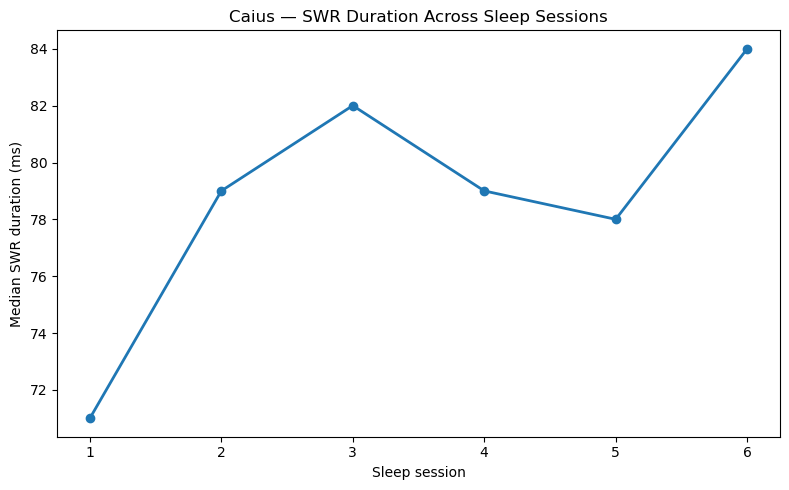

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    duration_summary["session_number"],
    duration_summary["median"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Median SWR duration (ms)")
plt.title("Caius — SWR Duration Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.show()

strength

In [17]:
amplitude_summary = (
    all_ripples
    .groupby("session_number")["max_zscore"]
    .agg(
        n="count",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        std="std"
    )
    .reset_index()
)

amplitude_summary["IQR"] = (
    amplitude_summary["q75"] -
    amplitude_summary["q25"]
)

amplitude_summary

,session_number,n,median,q25,q75,mean,std,IQR
0,1,1055,4.599547,3.661193,5.679972,4.803384,1.546411,2.018778
1,2,1323,4.905017,3.948907,5.886233,4.998752,1.413848,1.937326
2,3,1449,4.975255,3.844643,5.956075,4.978245,1.397120,2.111433
3,4,1722,4.594742,3.794876,5.307291,4.608812,1.117239,1.512415
4,5,1996,4.409251,3.748617,5.140162,4.488853,1.093007,1.391545
5,6,2029,4.424608,3.715446,5.101564,4.488524,1.121332,1.386118


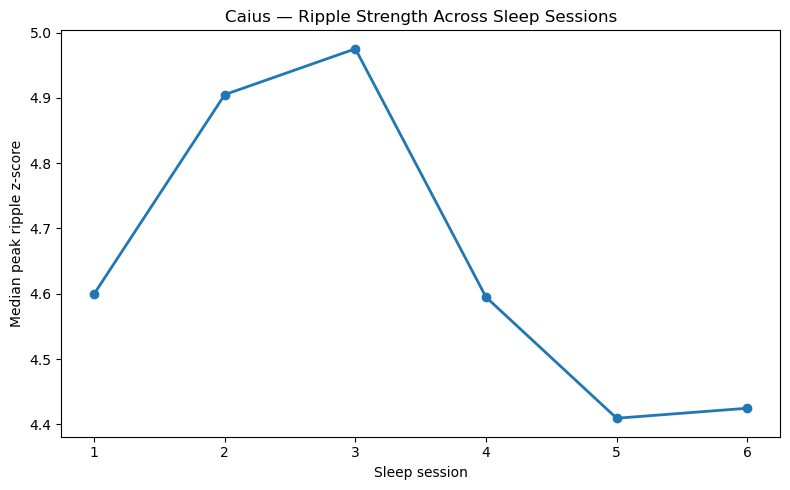

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    amplitude_summary["session_number"],
    amplitude_summary["median"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Median peak ripple z-score")
plt.title("Caius — Ripple Strength Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.show()

In [19]:
# ripple_summary.to_csv("caius_ripple_summary.csv", index=False)
# duration_summary.to_csv("caius_duration_summary.csv", index=False)
# amplitude_summary.to_csv("caius_amplitude_summary.csv", index=False)

In [31]:
import pandas as pd
import numpy as np

def calculate_session_detection_stats(
    nwb_file_name,
    nwbf,
    sessions
):
    
    # Get laser data once
    laser = (
        nwbf.processing["behavior"]
        .data_interfaces["behavioral_events"]
        .time_series["Laser"]
    )
    
    laser_data = laser.data[:]
    laser_timestamps = laser.timestamps[:]
    
    results = []

    for epoch_number, session in sessions.items():

        print(f"Processing {session}...")

        # =================================================
        # ONLINE
        # =================================================
        epoch_start, epoch_stop, epoch_name = (
            nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
        )

        mask = (
            (laser_timestamps > epoch_start) &
            (laser_timestamps <= epoch_stop)
        )

        laser_data_epoch = laser_data[mask]
        laser_timestamps_epoch = laser_timestamps[mask]

        # OFF -> ON transitions
        rising_edge_idx = np.where(
            np.diff(laser_data_epoch, prepend=0) == 1
        )[0]

        pulse_start_times = (
            laser_timestamps_epoch[rising_edge_idx]
        )

        # 20 pulses = one online train
        n_complete_trains = len(pulse_start_times) // 20

        online_trains = pulse_start_times[
            :n_complete_trains * 20
        ].reshape(
            n_complete_trains,
            20
        )

        # =================================================
        # OFFLINE
        # =================================================
        offline = (
            sgrip.RippleTimesV1()
            & {
                "nwb_file_name": nwb_file_name,
                "target_interval_list_name": session,
                "ripple_param_name": "default_trodes",
            }
        ).fetch1_dataframe()

        offline_start = offline["start_time"].to_numpy()
        offline_end = offline["end_time"].to_numpy()

        # =================================================
        # OFFLINE -> ONLINE MATCHING
        # Same logic as Marcus notebook
        # =================================================
        offline_has_online_match = []

        for start, end in zip(
            offline_start,
            offline_end
        ):

            pulse_matches = (
                (online_trains >= start) &
                (online_trains <= end)
            )

            offline_has_online_match.append(
                np.any(pulse_matches)
            )

        offline_has_online_match = np.array(
            offline_has_online_match
        )

        # =================================================
        # SUMMARY
        # =================================================
        n_offline = len(offline)
        n_online = len(online_trains)

        n_tp = offline_has_online_match.sum()
        n_fn = n_offline - n_tp

        capture_pct = (
            100 * n_tp / n_offline
            if n_offline > 0
            else np.nan
        )

        missed_pct = (
            100 * n_fn / n_offline
            if n_offline > 0
            else np.nan
        )

        results.append({
            "session": session,
            "offline_swr": n_offline,
            "online_detection": n_online,
            "TP": n_tp,
            "FN": n_fn,
            "capture_pct": capture_pct,
            "missed_pct": missed_pct
        })

        print(
            f"  Offline = {n_offline}, "
            f"Online = {n_online}, "
            f"TP = {n_tp}, "
            f"FN = {n_fn}, "
            f"Capture = {capture_pct:.1f}%"
        )

    return pd.DataFrame(results)

In [21]:
caius_sessions = {
    0: "01_s1",
    2: "03_s2",
    4: "05_s3",
    6: "07_s4",
    8: "09_s5",
    10: "11_s6",
}

In [24]:
import numpy as np
import pynwb
import spyglass.common as sgc

#this reads the raw nwb file so we can get laser DIO times
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Caius20260623.nwb", mode="r")
nwbf = io.read()

In [26]:
caius_stats = calculate_session_detection_stats(
    "Caius20260623_.nwb",
    nwbf,
    caius_sessions
)

caius_stats

Processing 01_s1...
  Offline = 1055, Online = 0, TP = 0, FN = 1055, Capture = 0.0%
Processing 03_s2...
  Offline = 1323, Online = 1971, TP = 917, FN = 406, Capture = 69.3%
Processing 05_s3...
  Offline = 1449, Online = 1814, TP = 1073, FN = 376, Capture = 74.1%
Processing 07_s4...
  Offline = 1722, Online = 2341, TP = 1232, FN = 490, Capture = 71.5%
Processing 09_s5...
  Offline = 1996, Online = 2672, TP = 609, FN = 1387, Capture = 30.5%
Processing 11_s6...
  Offline = 2029, Online = 2967, TP = 753, FN = 1276, Capture = 37.1%


,session,offline_swr,online_detection,TP,FN,capture_pct,missed_pct
0,01_s1,1055,0,0,1055,0.000000,100.000000
1,03_s2,1323,1971,917,406,69.312169,30.687831
2,05_s3,1449,1814,1073,376,74.051070,25.948930
3,07_s4,1722,2341,1232,490,71.544715,28.455285
4,09_s5,1996,2672,609,1387,30.511022,69.488978
5,11_s6,2029,2967,753,1276,37.111878,62.888122


In [ ]:
# caius_stats.to_csv("caius_online_offline_stats.csv", index=False)

In [33]:
# ============================================================
# Load laser data
# ============================================================

laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

print("Laser samples:", len(laser_data))
print("Laser timestamps:", len(laser_timestamps))

Laser samples: 470684
Laser timestamps: 470684


In [34]:
import pandas as pd
import numpy as np

# ============================================================
# CAIUS — FIRST-PULSE ALIGNMENT ANALYSIS
# ============================================================

caius_firstpulse_all_stats = []

for session_number, session in enumerate(sleep_sessions, start=1):

    print(f"Processing Caius {session}...")

    # ==================================================
    # 1. Offline SWRs
    # ==================================================
    offline_ripples_caius_firstpulse = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "ripple detection channels"
        }
    ).fetch1_dataframe()

    n_offline = len(
        offline_ripples_caius_firstpulse
    )

    # ==================================================
    # 2. Get session epoch
    # ==================================================
    epoch_index = (session_number - 1) * 2

    epoch_start, epoch_stop, _ = (
        nwbf.intervals["epochs"][epoch_index]
        .to_numpy()[0]
    )

    # ==================================================
    # 3. Extract laser signal
    # ==================================================
    laser_mask = (
        (laser_timestamps >= epoch_start) &
        (laser_timestamps <= epoch_stop)
    )

    laser_session = laser_data[laser_mask]
    laser_times_session = laser_timestamps[laser_mask]

    # ==================================================
    # 4. Find laser rising edges
    # ==================================================
    rising_edges = (
        np.diff(laser_session.astype(int)) == 1
    )

    pulse_start_times = (
        laser_times_session[1:][rising_edges]
    )

    # ==================================================
    # 5. Group into 20-pulse trains
    # ==================================================
    n_complete_trains = len(pulse_start_times) // 20

    if n_complete_trains > 0:

        online_trains = (
            pulse_start_times[
                :n_complete_trains * 20
            ]
            .reshape(
                n_complete_trains,
                20
            )
        )

    else:

        online_trains = np.empty((0, 20))

    n_online = len(online_trains)

    # ==================================================
    # 6. FIRST-PULSE matching
    # ==================================================
    offline_starts = (
        offline_ripples_caius_firstpulse["start_time"]
        .to_numpy()
    )

    offline_ends = (
        offline_ripples_caius_firstpulse["end_time"]
        .to_numpy()
    )

    # Only the first pulse from each online train
    first_pulses = online_trains[:, 0]

    first_pulse_match = np.zeros(
        n_offline,
        dtype=bool
    )

    for i, (start, end) in enumerate(
        zip(
            offline_starts,
            offline_ends
        )
    ):

        first_pulse_match[i] = np.any(
            (first_pulses >= start) &
            (first_pulses <= end)
        )

    # ==================================================
    # 7. TP / FN
    # ==================================================
    caius_firstpulse_tp = int(
        first_pulse_match.sum()
    )

    caius_firstpulse_fn = (
        n_offline -
        caius_firstpulse_tp
    )

    # ==================================================
    # 8. Percentages
    # ==================================================
    caius_firstpulse_capture_pct = (
        100 * caius_firstpulse_tp / n_offline
        if n_offline > 0
        else np.nan
    )

    caius_firstpulse_missed_pct = (
        100 * caius_firstpulse_fn / n_offline
        if n_offline > 0
        else np.nan
    )

    # ==================================================
    # 9. Save
    # ==================================================
    caius_firstpulse_all_stats.append({
        "session_number": session_number,
        "session": session,
        "offline_swr": n_offline,
        "online_detection": n_online,
        "TP_firstpulse": caius_firstpulse_tp,
        "FN_firstpulse": caius_firstpulse_fn,
        "capture_pct_firstpulse": caius_firstpulse_capture_pct,
        "missed_pct_firstpulse": caius_firstpulse_missed_pct
    })

    print(
        f"  Offline: {n_offline} | "
        f"Online: {n_online} | "
        f"TP (1st pulse): {caius_firstpulse_tp} | "
        f"FN: {caius_firstpulse_fn} | "
        f"Capture: {caius_firstpulse_capture_pct:.1f}%"
    )

# ============================================================
# Final Caius table
# ============================================================

caius_firstpulse_stats = pd.DataFrame(
    caius_firstpulse_all_stats
)

caius_firstpulse_stats

Processing Caius 01_s1...
  Offline: 1055 | Online: 0 | TP (1st pulse): 0 | FN: 1055 | Capture: 0.0%
Processing Caius 03_s2...
  Offline: 1323 | Online: 1971 | TP (1st pulse): 733 | FN: 590 | Capture: 55.4%
Processing Caius 05_s3...
  Offline: 1449 | Online: 1814 | TP (1st pulse): 554 | FN: 895 | Capture: 38.2%
Processing Caius 07_s4...
  Offline: 1722 | Online: 2341 | TP (1st pulse): 979 | FN: 743 | Capture: 56.9%
Processing Caius 09_s5...
  Offline: 1996 | Online: 2672 | TP (1st pulse): 319 | FN: 1677 | Capture: 16.0%
Processing Caius 11_s6...
  Offline: 2029 | Online: 2967 | TP (1st pulse): 421 | FN: 1608 | Capture: 20.7%


,session_number,session,offline_swr,online_detection,TP_firstpulse,FN_firstpulse,capture_pct_firstpulse,missed_pct_firstpulse
0,1,01_s1,1055,0,0,1055,0.000000,100.000000
1,2,03_s2,1323,1971,733,590,55.404384,44.595616
2,3,05_s3,1449,1814,554,895,38.233264,61.766736
3,4,07_s4,1722,2341,979,743,56.852497,43.147503
4,5,09_s5,1996,2672,319,1677,15.981964,84.018036
5,6,11_s6,2029,2967,421,1608,20.749138,79.250862


In [35]:
caius_firstpulse_mean = caius_firstpulse_stats.loc[
    caius_firstpulse_stats["session_number"] != 1,
    "capture_pct_firstpulse"
].mean()

print(
    f"Caius mean first-pulse capture (S2-S6): "
    f"{caius_firstpulse_mean:.1f}%"
)

Caius mean first-pulse capture (S2-S6): 37.4%


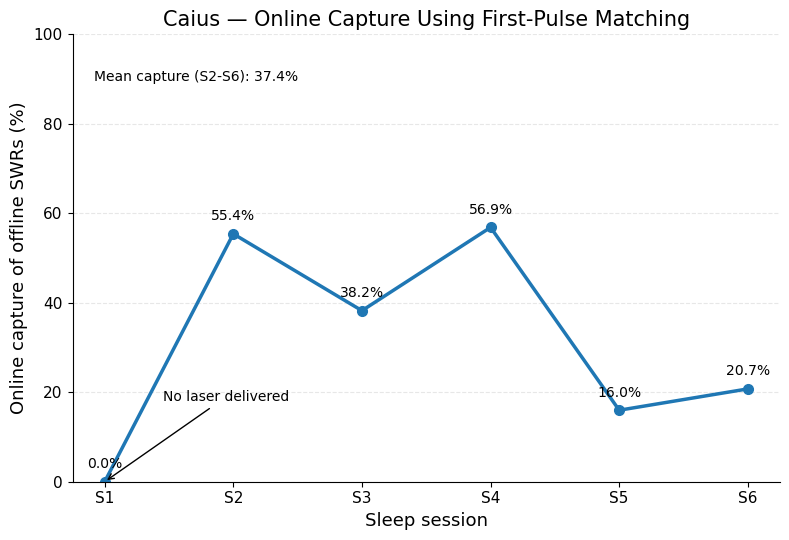

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5.5))

plt.plot(
    caius_firstpulse_stats["session_number"],
    caius_firstpulse_stats["capture_pct_firstpulse"],
    marker="o",
    markersize=7,
    linewidth=2.5
)

plt.annotate(
    "No laser delivered",
    xy=(1, 0),
    xytext=(1.45, 18),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1
    ),
    fontsize=10
)

plt.text(
    0.03,
    0.92,
    f"Mean capture (S2-S6): {caius_firstpulse_mean:.1f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="left",
    va="top"
)

plt.xlabel(
    "Sleep session",
    fontsize=13
)

plt.ylabel(
    "Online capture of offline SWRs (%)",
    fontsize=13
)

plt.title(
    "Caius — Online Capture Using First-Pulse Matching",
    fontsize=15
)

plt.xticks(
    [1, 2, 3, 4, 5, 6],
    ["S1", "S2", "S3", "S4", "S5", "S6"],
    fontsize=11
)

plt.yticks(
    range(0, 101, 20),
    fontsize=11
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for x, y in zip(
    caius_firstpulse_stats["session_number"],
    caius_firstpulse_stats["capture_pct_firstpulse"]
):
    plt.text(
        x,
        y + 3,
        f"{y:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# caius_firstpulse_stats.to_csv(
    "Caius_first_pulse_online_offline_stats.csv",
    index=False
)

print("Saved: Caius_first_pulse_online_offline_stats.csv")

Saved: Caius_first_pulse_online_offline_stats.csv
